<h1 style="text-align:center; font-size:40px; font-weight:bold;">
    Project
</h1>


[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.in2p3.fr%2Fenergy4climate%2Fpublic%2Feducation%2Fmachine_learning_for_climate_and_energy/master?filepath=book%2Fnotebooks%2Fprojects.ipynb)

# Project Introduction: Meteorological Drivers of Wind Power Generation

---

## 1. Project Overview

The primary objective of this study is to analyze the relationship between large-scale atmospheric conditions and the energy production of onshore wind farms.

We aim to determine if historical meteorological data can be effectively mapped to wind energy efficiency. Mathematically, we seek a function $f$ that links the atmospheric state matrix ($X$) to the observed power output ($y$):

$$y \approx f(X)$$

The nature of this relationship—whether linear, simple, or highly complex—is the subject of this investigation.

---

## 2. The Target Variable ($y$)

We aim to predict the **Capacity Factor** (`capacityfactor_wind_onshore`).

> **Definition:** The ratio of the actual electrical energy output to the maximum possible electrical energy output over a given period.

* **Range:** $y \in [0, 1]$ (representing 0% to 100% efficiency).
* **Interpretation:** A value of 0.0 indicates no production (calm wind or maintenance), while 1.0 indicates turbines operating at full rated power.

---

## 3. The Input Data ($X$)

The predictor variables are derived from the **MERRA-2** (Modern-Era Retrospective analysis for Research and Applications) reanalysis dataset, spanning the period 2010-2019. These variables characterize the **aerodynamic** and **thermodynamic** state of the atmosphere.

### A. Wind Dynamics
Wind vectors are provided at two vertical levels to capture both surface speed and vertical wind shear.

| Variable Name | Level | Description |
| :--- | :--- | :--- |
| **`zonal_wind`** ($u$) | Surface | West-to-East wind component. |
| **`meridional_wind`** ($v$) | Surface | South-to-North wind component. |
| **`upper_zonal_wind`** | Upper | High-altitude West-to-East component. |
| **`upper_meridional_wind`**| Upper | High-altitude South-to-North component. |



### B. Thermodynamics & Synoptic Context
These variables account for air density variations ($P \propto \rho$) and the large-scale weather regime.

| Variable Name | Category | Role in Prediction |
| :--- | :--- | :--- |
| **`surface_density`** | Thermodynamics | Directly affects power output (Air Density $\rho$). |
| **`surface_temperature`** | Thermodynamics | Influences density and potential icing conditions. |
| **`surface_specific_humidity`**| Thermodynamics | Affects air mass properties and stability. |
| **`height_500`** | Synoptic | **Geopotential height at 500hPa**. Proxy for high/low pressure systems. |

## Reading the data

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import numpy as np

# Directories where you saved the data
data_dir_energy = Path('energy_france')
data_dir_climate = Path('climate_france')
                        
# Template filenames
filename_mask = 'mask_datagouv_french_regions_merra2_Nx_France.nc'
filename_climate = 'merra2_area_selection_output_{}_merra2_2010-2019.nc'
filename_energy = 'reseaux_energies_{}.csv'


# Read energy variable and plot time series
variable_name = 'capacityfactor_wind-onshore'
filename = filename_energy.format(variable_name)
filepath = Path(data_dir_energy, filename)
df_energy_wind = pd.read_csv(filepath, index_col=0, header=0, parse_dates=True)



In [2]:
# Read a climate variable and plot its mean over time
filepath_mask = Path(data_dir_climate, filename_mask)
ds_mask = xr.load_dataset(filepath_mask)
da_mask = ds_mask['mask']

variable_name = 'zonal_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_zonal_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_zonal_wind = da_climate_zonal_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_zonal_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_zonal_wind.plot.line(x='time')

variable_name = 'upper_zonal_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_upper_zonal_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_upper_zonal_wind = da_climate_upper_zonal_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_upper_zonal_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_upper_zonal_wind.plot.line(x='time')

variable_name = 'meridional_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_meridional_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_meridional_wind = da_climate_meridional_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_meridional_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_meridional_wind.plot.line(x='time')

variable_name = 'upper_meridional_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_upper_meridional_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_upper_meridional_wind = da_climate_upper_meridional_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_upper_meridional_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_upper_meridional_wind.plot.line(x='time')


variable_name = 'height_500'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_height_500 = xr.load_dataset(filepath)[variable_name]
da_climate_height_500 = da_climate_height_500.groupby(da_mask).mean().rename(mask='region')
da_climate_height_500['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_height_500.plot.line(x='time')


## Create the dataframe 

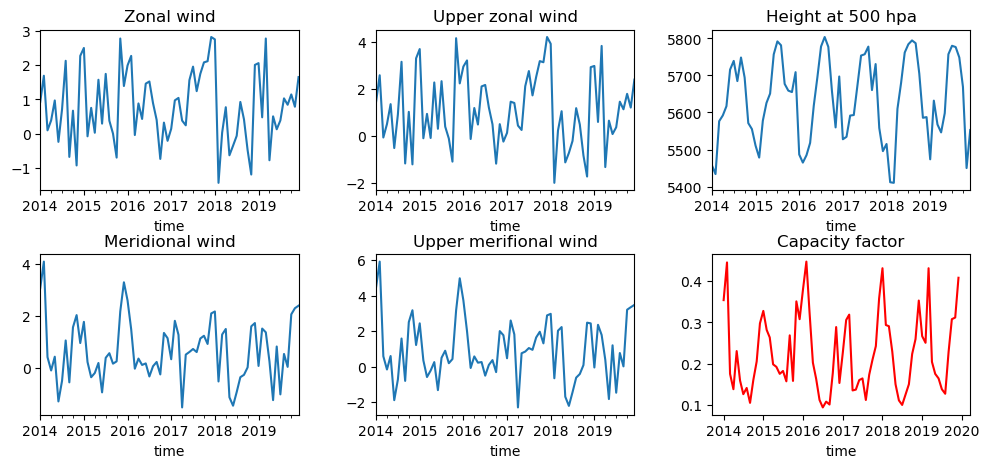

In [3]:
region_names = ds_mask['region'].values
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

variables = {
    'zonal_wind': da_climate_reg_zonal_wind,
    'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
    'meridional_wind': da_climate_reg_meridional_wind,
    'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
    'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
}


region_names = ds_mask['region'].values

# récupération de l'indice de la région Grand Est
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

df_grand_est = pd.DataFrame()

for var_name, da in variables.items():

    # on vérifie le nom de la dimension région
    region_dim = 'region' if 'region' in da.coords else 'mask'

    # extraction
    df_grand_est[var_name] = da.isel({region_dim: idx_grand_est}).to_pandas()

df_grand_est = df_grand_est.resample('MS').mean().loc['2014-01-01':'2019-12-31']

df_grand_est["capacityfactor_wind_onshore"] = df_energy_wind["Grand Est"].loc['2014-01-01':'2019-12-31']

plt.figure(figsize=(12,5))
plt.subplot(2,3,1)
df_grand_est['zonal_wind'].plot.line(x='time')
plt.title('Zonal wind')

plt.subplot(2,3,2)
df_grand_est['upper_zonal_wind'].plot.line(x='time',y='upper_zonal_wind')
plt.title('Upper zonal wind')

plt.subplot(2,3,4)
df_grand_est['meridional_wind'].plot.line(x='time')
plt.title('Meridional wind')

plt.subplot(2,3,5)
df_grand_est['upper_meridional_wind'].plot.line(x='time')
plt.title('Upper merifional wind')

plt.subplot(2,3,3)
df_grand_est['height_500'].plot.line(x='time')
plt.title('Height at 500 hpa')


plt.subplot(2,3,6)
plt.plot(df_grand_est.index, df_grand_est['capacityfactor_wind_onshore'], color = 'red')
plt.xlabel('time')
plt.title('Capacity factor')

plt.subplots_adjust(
    wspace=0.3,   # espace horizontal entre subplots
    hspace=0.4    # espace vertical entre subplots
)

## Try a simple linear regression 

We take all the monthly data and we create a model. With this we try to estimate the R^2 per region and see if we can make a global model

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# --- 1. INITIALISATION ---
# On vide df_global pour être sûr de repartir à zéro
df_global = pd.DataFrame()

# Liste pour stocker les scores de CHAQUE région (Approche Locale)
local_scores = []

# --- 2. BOUCLE SUR LES RÉGIONS ---
for region_name in region_names:
    idx_region = np.where(region_names == region_name)[0][0]

    # --- A. Extraction des données (Code inchangé) ---
    variables = {
        'zonal_wind': da_climate_reg_zonal_wind,
        'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
        'meridional_wind': da_climate_reg_meridional_wind,
        'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
        'height_500': da_climate_height_500,  
    }

    df_region = pd.DataFrame()
    for var_name, da in variables.items():
        region_dim = 'region' if 'region' in da.coords else 'mask'
        df_region[var_name] = da.isel({region_dim: idx_region}).to_pandas()

    df_region = df_region.resample('MS').mean().loc['2014-01-01':'2019-12-31']

    # --- B. Récupération Target (Y) ---
    # Gestion des noms bizarres
    if region_name == 'Ile-de-France':
        col_target = 'Île-de-France'
    elif region_name == 'Pays-de-la-Loire':
        col_target = 'Pays de la Loire'
    elif region_name == 'PACA':
        col_target = "Provence-Alpes-Côte d'Azur"
    else:
        col_target = region_name
        
    df_region["capacityfactor_wind_onshore"] = df_energy_wind[col_target].loc['2014-01-01':'2019-12-31']

    # --- C. CALCUL DU SCORE LOCAL (Approche Régionale) ---
    # On entraîne et on teste juste sur CETTE région
    X_loc = df_region[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
    y_loc = df_region['capacityfactor_wind_onshore'].values
    
    # Scaling Local
    scaler_loc = StandardScaler()
    X_loc_scaled = scaler_loc.fit_transform(X_loc)
    
    # Score Local
    reg_loc = LinearRegression()
    # cv=6 pour les 6 années
    cv_loc = cross_val_score(reg_loc, X_loc_scaled, y_loc, cv=6, scoring='r2').mean()
    local_scores.append(cv_loc)

    # --- D. CONSTRUCTION DU DATASET GLOBAL ---
    # On ajoute cette région au grand tout
    df_global = pd.concat([df_global, df_region], axis=0)


# --- 3. CALCUL DU SCORE GLOBAL (Approche Unique) ---
# Maintenant que df_global est plein et propre
X_glob = df_global[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
y_glob = df_global['capacityfactor_wind_onshore'].values

scaler_glob = StandardScaler()
X_glob_scaled = scaler_glob.fit_transform(X_glob)

reg_glob = LinearRegression()
# cv=6 ici va découper le dataset mélangé, c'est une approximation mais acceptable pour comparer
cv_global = cross_val_score(reg_glob, X_glob_scaled, y_glob, cv=6, scoring='r2').mean()


# --- 4. AFFICHAGE DES RÉSULTATS ---
mean_local_score = np.mean(local_scores)

print(f"--- RÉSULTATS COMPARATIFS ---")
print(f"Score du Modèle Global (1 seul modèle)      : {cv_global:.4f}")
print(f"Moyenne des Modèles Locaux (12 modèles)     : {mean_local_score:.4f}")
print(f"Gain en passant au Local                    : +{mean_local_score - cv_global:.4f}")

--- RÉSULTATS COMPARATIFS ---
Score du Modèle Global (1 seul modèle)      : 0.4617
Moyenne des Modèles Locaux (12 modèles)     : 0.5961
Gain en passant au Local                    : +0.1344


We have better results when we use one model per region, so we will take one region and see what is the better model.

For the next step, we will take one particular region : Grand Est. 

R2 cross validation: 0.6833716962556348


Text(0.5, 1.0, 'Capacity factor')

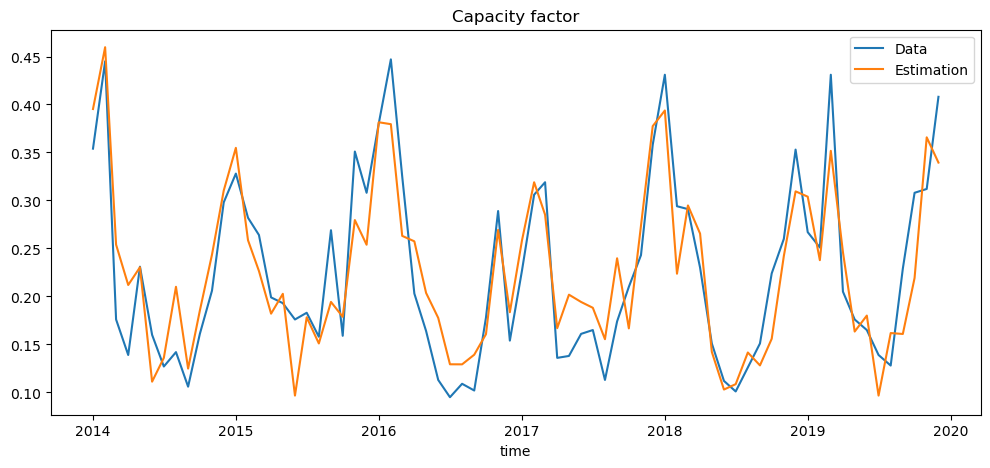

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


X_train = df_grand_est[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
y_train = df_grand_est['capacityfactor_wind_onshore'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Régression
reg = LinearRegression()
reg.fit(X_scaled, y_train)


#print("Intercept :", reg.intercept_)
#print("Coefficients :", reg.coef_)

y_pred = reg.predict(X_scaled)

cv_scores = cross_val_score(reg, X_scaled, y_train, cv=6, scoring='r2')
mean_score = cv_scores.mean()

print("R2 cross validation:", mean_score)

plt.figure(figsize=(12,5))
plt.plot(df_grand_est.index,y_train,label='Data')
plt.plot(df_grand_est.index,y_pred,label='Estimation')
plt.legend()
plt.xlabel('time')
plt.title('Capacity factor')

## Testing Physics-Informed Features

In this section, we want to **test a hypothesis**: can we improve our model's performance by explicitly calculating features based on wind physics?

We are not sure yet if this will provide a significant boost, but we aim to explore three specific transformations:

* **Speed & Direction:** Does the model learn better with explicit **Wind Speed** ($w$) and **Angle** ($\theta$) inputs rather than raw Cartesian vectors ($u, v$)?
* **The "Cube" Law ($v^3$):** Since power is theoretically proportional to the cube of the speed ($P \propto v^3$), we will test if pre-calculating this term helps linearize the problem for our simpler models.
* **Shear & Cycles:** We will investigate if adding **Vertical Wind Shear** (stability proxy) and **Cyclical Time Features** (preserving day/night continuity) brings meaningful context to the prediction.

We will compute these features and **compare the results** against our baseline to validate (or reject) their usefulness.

In [6]:
import numpy as np

# --- 1. FEATURE ENGINEERING ---

# A. Wind Speed (Magnitude): sqrt(u^2 + v^2)
df_grand_est['wind_speed'] = np.sqrt(df_grand_est['zonal_wind']**2 + df_grand_est['meridional_wind']**2)
df_grand_est['upper_wind_speed'] = np.sqrt(df_grand_est['upper_zonal_wind']**2 + df_grand_est['upper_meridional_wind']**2)

# B. Wind Angle (Direction): arctan2(v, u)
# Note: Keeping radians is fine for the model
df_grand_est['wind_angle'] = np.arctan2(df_grand_est['meridional_wind'], df_grand_est['zonal_wind'])
df_grand_est['upper_wind_angle'] = np.arctan2(df_grand_est['upper_meridional_wind'], df_grand_est['upper_zonal_wind'])

# C. Cube Law (Non-linearity)
# Power is theoretically proportional to v^3
df_grand_est['wind_speed_cubed'] = df_grand_est['wind_speed']**3

# D. Shear
# Difference between Upper and Surface speeds (Proxy for stability)
df_grand_est['shear_speed'] = df_grand_est['upper_wind_speed'] - df_grand_est['wind_speed']

# E. Cyclical Time (Seasonality)
# Encoding month (1-12) onto a circle so Dec (12) is close to Jan (1)
df_grand_est['month_sin'] = np.sin(2 * np.pi * df_grand_est.index.month / 12)
df_grand_est['month_cos'] = np.cos(2 * np.pi * df_grand_est.index.month / 12)

# Preview
print("Generated new features:")
display(df_grand_est[['wind_speed','wind_angle','upper_wind_angle', 'wind_speed_cubed', 'shear_speed', 'month_sin','month_cos','upper_wind_speed']].head())


Generated new features:


,wind_speed,wind_angle,upper_wind_angle,wind_speed_cubed,shear_speed,month_sin,month_cos,upper_wind_speed
time,,,,,,,,
2014-01-01,3.209754,1.276944,1.257797,33.068565,1.483180,0.500000,8.660254e-01,4.692934
2014-02-01,4.427172,1.178148,1.158928,86.771927,2.023317,0.866025,5.000000e-01,6.450490
2014-03-01,0.435942,1.344057,1.683781,0.082849,0.154782,1.000000,6.123234e-17,0.590724
2014-04-01,0.398390,-0.221634,-0.298133,0.063230,0.129369,0.866025,-5.000000e-01,0.527759
2014-05-01,1.066958,0.426800,0.419160,1.214623,0.413551,0.500000,-8.660254e-01,1.480509


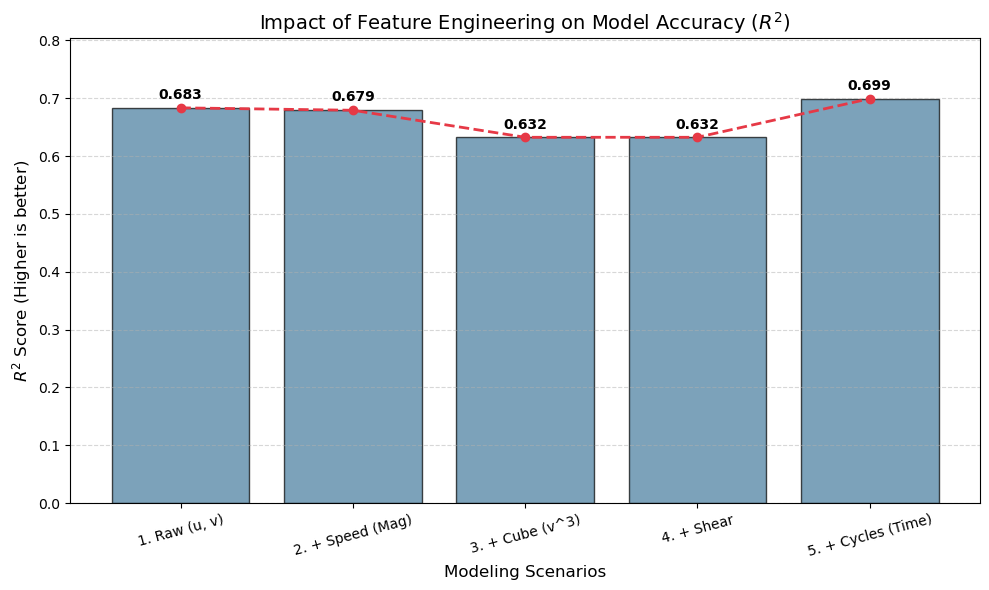

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# --- CONFIGURATION DES SCÉNARIOS ---
# On définit étape par étape ce qu'on rajoute
scenarios = [
    ("1. Raw (u, v)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500']),
     
    ("2. + Speed (Mag)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed']),
      
    ("3. + Cube (v^3)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed']),
      
    ("4. + Shear", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed']),
      
    ("5. + Cycles (Time)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed', 'month_sin', 'month_cos'])
]

# --- BOUCLE D'ENTRAÎNEMENT ---
scores = []
names = []

# Cible fixe
y = df_grand_est['capacityfactor_wind_onshore'].values

for name, features in scenarios:
    # 1. Préparation X
    X = df_grand_est[features].values
    
    # 2. Scaling
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

    # 3. Fit
    reg = LinearRegression()
    reg.fit(X_scaled, y)
    
    # 4. Score
    r2 = cross_val_score(reg, X_scaled, y, cv=6, scoring='r2').mean()
    scores.append(r2)
    names.append(name)

# --- VISUALISATION ---
plt.figure(figsize=(10, 6))

# Tracer les barres
bars = plt.bar(names, scores, color='#457b9d', edgecolor='black', alpha=0.7)

# Tracer une ligne pour voir la tendance
plt.plot(names, scores, color='#e63946', marker='o', linewidth=2, linestyle='--')

# Ajouter les valeurs exactes sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.title("Impact of Feature Engineering on Model Accuracy ($R^2$)", fontsize=14)
plt.ylabel("$R^2$ Score (Higher is better)", fontsize=12)
plt.xlabel("Modeling Scenarios", fontsize=12)
plt.ylim(0, max(scores) * 1.15) # Un peu d'espace en haut
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15) # Pencher le texte pour qu'il soit lisible
plt.tight_layout()
plt.show()

Try if redundancy is a problem 

Strategy                  | Train R²   | CV R²      | Gap (Overfitting)
-----------------------------------------------------------------
1. Old (Raw Data)         | 0.7887     | 0.6834     | 0.1053
2. New (Physics)          | 0.7837     | 0.6077     | 0.1761
3. All-in (Redundant)     | 0.8479     | 0.5528     | 0.2952


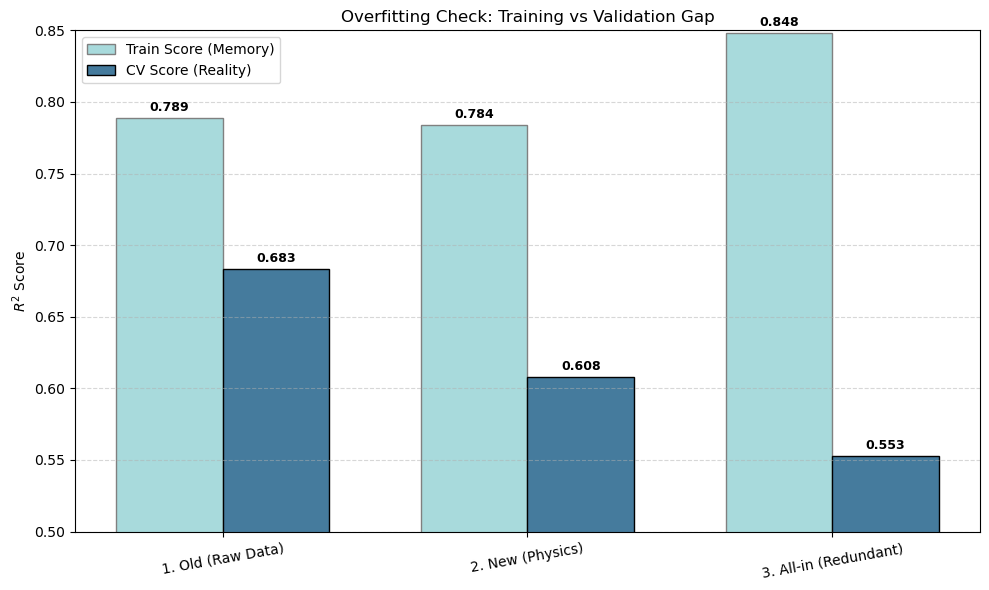

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# --- 1. DÉFINITION DES STRATÉGIES ---
strategies = [
    ("1. Old (Raw Data)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500']),

    ("2. New (Physics)", 
     ['wind_speed_cubed', 'shear_speed', 'wind_angle', 'upper_wind_angle', 
      'month_sin', 'month_cos', 'height_500']),

    ("3. All-in (Redundant)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed', 
      'wind_angle', 'upper_wind_angle', 'month_sin', 'month_cos', 'height_500'])
]

# --- 2. CALCUL DES SCORES (TRAIN vs CV) ---
train_scores = []
cv_scores = []
names = []
y = df_grand_est['capacityfactor_wind_onshore'].values

print(f"{'Strategy':<25} | {'Train R²':<10} | {'CV R²':<10} | {'Gap (Overfitting)'}")
print("-" * 65)

for name, features in strategies:
    X = df_grand_est[features].values
    
    # Scaling manuel
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    
    reg = LinearRegression()
    
    # A. Score d'Entraînement (La "Triche" / Mémoire)
    reg.fit(X_scaled, y)
    s_train = reg.score(X_scaled, y)
    
    # B. Score de Validation (La Réalité / Généralisation)
    # On utilise cv=6 pour coller aux années si tu as 6 ans de données
    cv_vals = cross_val_score(reg, X_scaled, y, cv=6, scoring='r2')
    s_cv = cv_vals.mean()
    
    train_scores.append(s_train)
    cv_scores.append(s_cv)
    names.append(name)
    
    print(f"{name:<25} | {s_train:.4f}     | {s_cv:.4f}     | {s_train - s_cv:.4f}")

# --- 3. VISUALISATION DU GAP ---
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Barres Train (Bleu clair)
rects1 = ax.bar(x - width/2, train_scores, width, label='Train Score (Memory)', color='#a8dadc', edgecolor='grey')
# Barres CV (Bleu foncé - La vraie performance)
rects2 = ax.bar(x + width/2, cv_scores, width, label='CV Score (Reality)', color='#457b9d', edgecolor='black')

ax.set_ylabel('$R^2$ Score')
ax.set_title('Overfitting Check: Training vs Validation Gap')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.legend()
ax.set_ylim(0.5, 0.85) # Zoom sur la zone intéressante
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Fonction pour mettre les étiquettes
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

##  Regularization: Lasso & Ridge

With the addition of our physics-informed features (like $v^3$, shear, etc.) alongside the raw data, we have introduced **redundancy** and **collinearity** (high correlation between variables). Standard Linear Regression can struggle in this context and may overfit.

In this section, we will test two regularization techniques to see if constraining the model yields better results:

* Ridge Regression
* Lasso Regression

Dataset                             | Best Ridge | Best Lasso
-----------------------------------------------------------------
1. Raw Data                         | 0.6921     | 0.6863
2. All-in (Redundant)               | 0.6973     | 0.6926
3. Raw + Cycles                     | 0.7215     | 0.7155


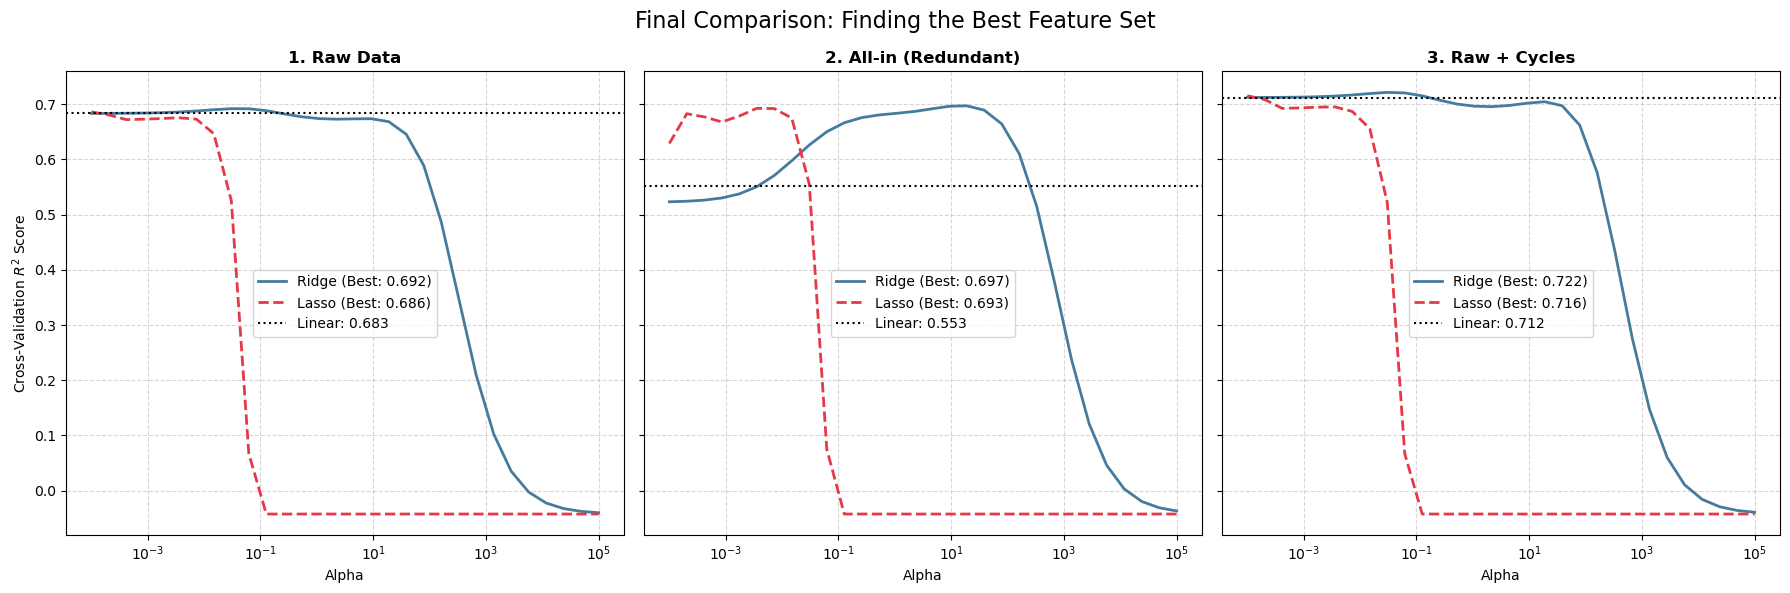

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# --- 1. CONFIGURATION DES 3 DATASETS ---

# A
features_raw = ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500']

# B.
features_all = [
    'zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
    'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed', 
    'wind_angle', 'upper_wind_angle', 'month_sin', 'month_cos'
]

# C
features_raw_cycles = features_raw + ['month_sin', 'month_cos']

datasets = {
    "1. Raw Data": features_raw,
    "2. All-in (Redundant)": features_all,
    "3. Raw + Cycles": features_raw_cycles
}

# Paramètres
alphas = np.logspace(-4, 5, 30)
y = df_grand_est['capacityfactor_wind_onshore'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

print(f"{'Dataset':<35} | {'Best Ridge':<10} | {'Best Lasso'}")
print("-" * 65)

for i, (name, cols) in enumerate(datasets.items()):
    ax = axes[i]
    
    # A. Préparation
    X = df_grand_est[cols].values
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    
    # B. Baseline (Linear)
    lin = LinearRegression()
    baseline = np.mean(cross_val_score(lin, X_scaled, y, cv=6, scoring='r2'))
    
    # C. Alphas Loop
    scores_ridge = []
    scores_lasso = []
    
    for a in alphas:
        r = Ridge(alpha=a)
        scores_ridge.append(np.mean(cross_val_score(r, X_scaled, y, cv=6, scoring='r2')))
        
        l = Lasso(alpha=a, max_iter=10000)
        scores_lasso.append(np.mean(cross_val_score(l, X_scaled, y, cv=6, scoring='r2')))
    
    # D. Meilleurs Scores pour affichage
    best_ridge = max(scores_ridge)
    best_lasso = max(scores_lasso)
    
    # E. Plotting
    ax.semilogx(alphas, scores_ridge, label=f'Ridge (Best: {best_ridge:.3f})', color='#457b9d', linewidth=2)
    ax.semilogx(alphas, scores_lasso, label=f'Lasso (Best: {best_lasso:.3f})', color='#e63946', linewidth=2, linestyle='--')
    ax.axhline(baseline, color='black', linestyle=':', label=f'Linear: {baseline:.3f}')
    
    # Esthétique
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Alpha')
    if i == 0: ax.set_ylabel('Cross-Validation $R^2$ Score')
    ax.grid(True, which="both", linestyle='--', alpha=0.5)
    ax.legend()
    
    print(f"{name:<35} | {best_ridge:.4f}     | {best_lasso:.4f}")

plt.suptitle("Final Comparison: Finding the Best Feature Set", fontsize=16)
plt.tight_layout()
plt.show()

### Simplicity and Context Prevail

After testing multiple feature engineering strategies and regularization techniques, we have arrived at an interesting and somewhat counter-intuitive conclusion regarding the modeling of wind power generation.

#### 1. The Winning Strategy: Raw Data + Time Cycles
Contrary to our initial hypothesis, complex physics-informed feature engineering (calculating $v^3$, shear, or explicit angles) did not yield the best performance.

The most accurate and robust model was achieved using the **simplest feature set**:
* **Raw Cartesian Vectors** ($u, v$): These handle wind direction continuously, avoiding the mathematical discontinuities introduced by calculating angles in radians.
* **Time Cycles** (`month_sin`, `month_cos`): Adding seasonality was the critical missing piece. It provides the model with implicit context regarding air density and atmospheric stability (e.g., winter vs. summer conditions).


## Estimate with an anomaly

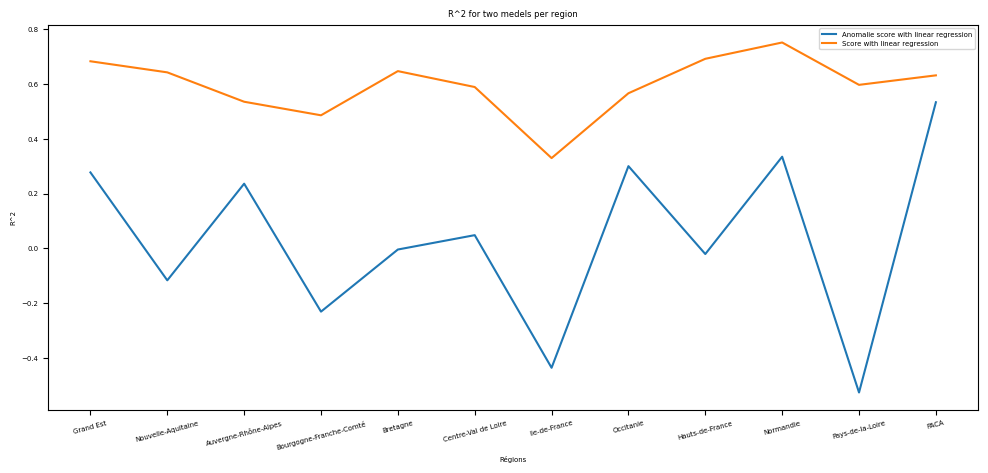

--- RÉSULTATS COMPARATIFS ---
Moyenne des Modèles Locaux avec anomaile (12 modèles)      : 0.0326
Moyenne des Modèles Locaux (12 modèles)     : 0.5961


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

region_names = ds_mask['region'].values
r2_region = []
df_global = pd.DataFrame()   

for region_name in region_names :
    idx_region = np.where(region_names == region_name)[0][0]

    variables = {
        'zonal_wind': da_climate_reg_zonal_wind,
        'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
        'meridional_wind': da_climate_reg_meridional_wind,
        'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
        'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
    }

    df_region = pd.DataFrame()

    for var_name, da in variables.items():
        region_dim = 'region' if 'region' in da.coords else 'mask'
        df_region[var_name] = da.isel({region_dim: idx_region}).to_pandas()

    df_region = df_region.resample('MS').mean().loc['2014-01-01':'2019-12-31']

    if region_name == 'Ile-de-France' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Île-de-France'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'Pays-de-la-Loire' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Pays de la Loire'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'PACA' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Provence-Alpes-Côte d\'Azur'].loc['2014-01-01':'2019-12-31']
    else:
        df_region["capacityfactor_wind_onshore"] = df_energy_wind[region_name].loc['2014-01-01':'2019-12-31']

    df_region_mean = df_region.groupby(df_region.index.month).transform("mean")
    df_region_anomaly = df_region - df_region_mean
    
    X_train = df_region_anomaly[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
    y_train = df_region_anomaly['capacityfactor_wind_onshore'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Régression
    reg = LinearRegression()
    reg.fit(X_scaled, y_train)
    
    cv_scores = cross_val_score(reg, X_scaled, y_train, cv=6, scoring='r2')
    mean_score = cv_scores.mean()
    r2_region.append(mean_score)


plt.figure(figsize=(12,5))
plt.rcParams['font.size'] = 5
plt.plot(region_names,r2_region,label = "Anomalie score with linear regression")
plt.plot(region_names,local_scores,label = "Score with linear regression")
plt.xlabel("Régions")
plt.ylabel("R^2")
plt.legend()
plt.title("R^2 for two medels per region")
plt.xticks(rotation=15) # Pencher le texte pour qu'il soit lisible
plt.show()

print(f"--- RÉSULTATS COMPARATIFS ---")
print(f"Moyenne des Modèles Locaux avec anomaile (12 modèles)      : {np.mean(r2_region):.4f}")
print(f"Moyenne des Modèles Locaux (12 modèles)     : {mean_local_score:.4f}")

Using anomalie to fit is not good, for all the regions it is better not just take into accout the anomalie.

# Validation
Now we will come back to a daily data and see if our modelisation is good or not compare to the reality

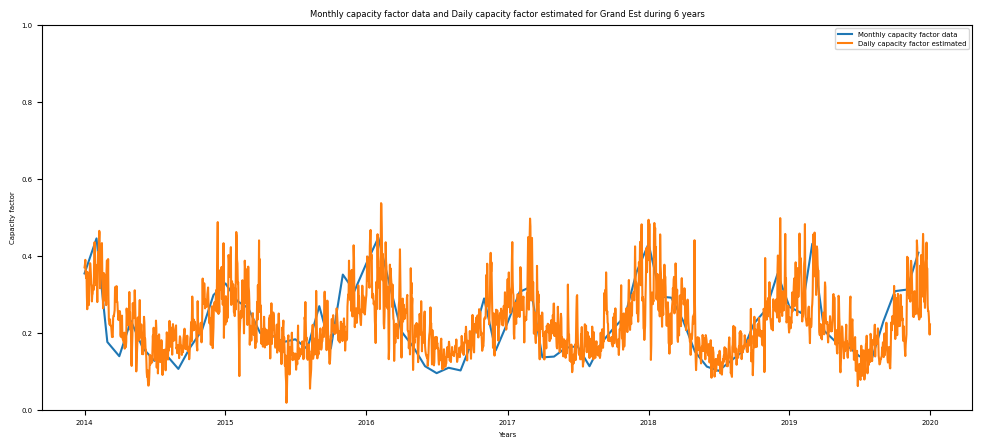

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

region_names = ds_mask['region'].values
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

variables = {
    'zonal_wind': da_climate_reg_zonal_wind,
    'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
    'meridional_wind': da_climate_reg_meridional_wind,
    'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
    'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
}


region_names = ds_mask['region'].values

# récupération de l'indice de la région Grand Est
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

df_grand_est = pd.DataFrame()

for var_name, da in variables.items():

    # on vérifie le nom de la dimension région
    region_dim = 'region' if 'region' in da.coords else 'mask'

    # extraction
    df_grand_est[var_name] = da.isel({region_dim: idx_grand_est}).to_pandas()

df_grand_est["capacityfactor_wind_onshore"] = df_energy_wind["Grand Est"].loc['2014-01-01':'2019-12-31']

df_grand_est_month = df_grand_est.resample('MS').mean().loc['2014-01-01':'2019-12-31']
df_grand_est_day = df_grand_est.resample('D').mean().loc['2014-01-01':'2019-12-31']
#df_grand_est_day = df_grand_est.loc['2014-01-01':'2019-12-31']

df_grand_est_month['month_sin'] = np.sin(2 * np.pi * df_grand_est_month.index.month / 12)
df_grand_est_month['month_cos'] = np.cos(2 * np.pi * df_grand_est_month.index.month / 12)

df_grand_est_day['month_sin'] = np.sin(2 * np.pi * df_grand_est_day.index.month / 12)
df_grand_est_day['month_cos'] = np.cos(2 * np.pi * df_grand_est_day.index.month / 12)


y_train = df_grand_est_month['capacityfactor_wind_onshore'].values
X_train = df_grand_est_month[cols].values
X_train_scaled = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)

X_test = df_grand_est_day[cols].values
X_test_scaled = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)

lin = LinearRegression()
r = Ridge(alpha=0.06)

lin.fit(X_train_scaled,y_train)

y_pred = lin.predict(X_test_scaled)

plt.figure(figsize=(12,5))
plt.plot(df_grand_est_month.index,y_train,label = "Monthly capacity factor data")
plt.plot(df_grand_est_day.index,y_pred,label = "Daily capacity factor estimated")
plt.title("Monthly capacity factor data and Daily capacity factor estimated for Grand Est during 6 years")
plt.ylim(0, 1)
plt.xlabel("Years")
plt.ylabel("Capacity factor")
plt.legend()
plt.show()

## Comparison with RTE Daily Capacity Factor Data

To compare our results, we examined RTE's **daily capacity factor** for the **Grand-Est** region during **January 2020** and **January 2025**.

The RTE dataset shows that the **daily capacity factor exceeds 50% on at least 20–30 days each year**.  
In contrast, with our model, this **never happens**.

This suggests that:

- The model is a **good approximation** for estimating the **monthly capacity factor**,  
- But it **should not be used to extrapolate daily capacity factors**,  
- Because daily variability is much higher, and the model does not reproduce this short-term behavior.

## Importance of Daily Data

Using daily values would be valuable because:

- It provides **many more data points**,  
- Allowing for a more robust evaluation of the model,  
- And offering insight into how well the model captures **short-term wind fluctuations**.


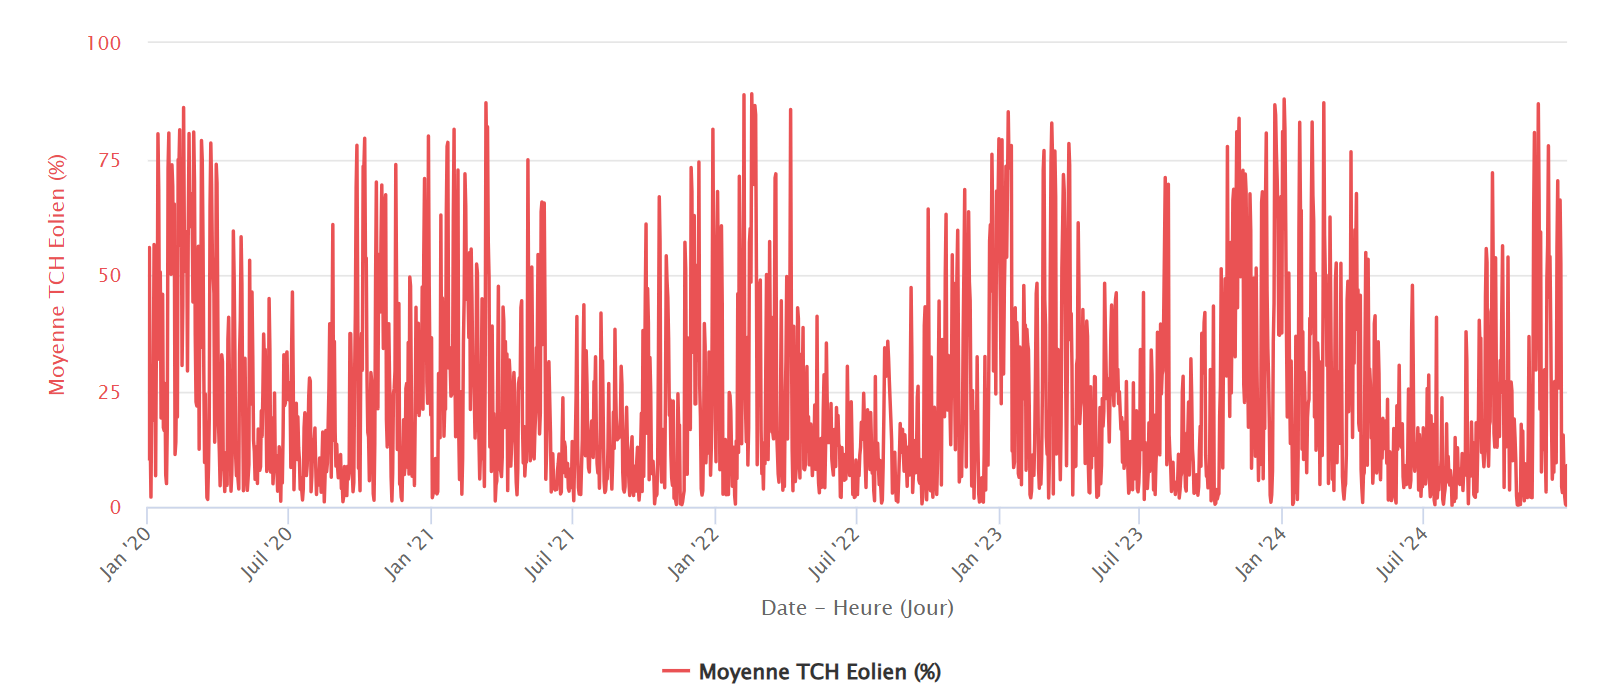

***
## Credit

[//]: # "This notebook is part of [E4C Interdisciplinary Center - Education](https://gitlab.in2p3.fr/energy4climate/public/education)."
Contributors include Bruno Deremble and Alexis Tantet.
Several slides and images are taken from the very good [Scikit-learn course](https://inria.github.io/scikit-learn-mooc/).

<br>

<div style="display: flex; height: 70px">
    
<img alt="Logo LMD" src="images/logos/logo_lmd.jpg" style="display: inline-block"/>

<img alt="Logo IPSL" src="images/logos/logo_ipsl.png" style="display: inline-block"/>

<img alt="Logo E4C" src="images/logos/logo_e4c_final.png" style="display: inline-block"/>

<img alt="Logo EP" src="images/logos/logo_ep.png" style="display: inline-block"/>

<img alt="Logo SU" src="images/logos/logo_su.png" style="display: inline-block"/>

<img alt="Logo ENS" src="images/logos/logo_ens.jpg" style="display: inline-block"/>

<img alt="Logo CNRS" src="images/logos/logo_cnrs.png" style="display: inline-block"/>
    
</div>

<hr>

<div style="display: flex">
    <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0; margin-right: 10px" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>
    <br>This work is licensed under a &nbsp; <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/">Creative Commons Attribution-ShareAlike 4.0 International License</a>.
</div>